# This notebook plots the number density of MCS on a map

---

### Preprocessing — run once per source (outside this notebook)

The heavy lifting (read netCDF, filter to region, flatten jagged arrays) is done by
`scripts/combine_filter_mcs_trackstats.py`.  It reads yearly `mcs_tracks_final_*.nc`
files, filters tracks to a lat/lon box, flattens each file to a tidy DataFrame (one
row per valid time step, clipped to `track_duration`), and writes a single compressed
Parquet file per source.

```bash
# SCREAM
python scripts/combine_filter_mcs_trackstats.py \
    --indir /pscratch/sd/f/feng045/SCREAM-decadal/ne1024/stats \
    --region tropics --start-year 1995 --end-year 2005

# IMERG
python scripts/combine_filter_mcs_trackstats.py \
    --indir /pscratch/sd/f/feng045/waccem/mcs_global_v3/MCSMIP/stats \
    --pattern 'mcsmip_mcs_tracks_final_*.nc' \
    --region tropics --start-year 1998 --end-year 2024
```

Re-run the script whenever the year range changes; re-run this notebook to update plots.

Run this notebook on a NERSC compute node due to high memory use.

---

In [35]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import copy
%matplotlib inline

In [65]:
# ── Source configuration ───────────────────────────────────────────────────────
# Each entry: label, combined_dir (where the preprocessed Parquet lives),
#             region, and per-source start/end year.
#
# The year range must match what was passed to combine_filter_mcs_trackstats.py
# because they are baked into the Parquet filename:
#   mcs_tracks_final_combined_{region}_{start_year}_{end_year}.parquet
REGION = 'global'

SOURCES = {
    'obs': dict(
        label        = 'IMERG',
        combined_dir = '/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/mcs_global_v3/MCSMIP/stats',
        region       = REGION,
        start_year   = 2007,   # ← edit to change range (re-run script if changed)
        end_year     = 2017,
    ),
    'm1': dict(
        label        = 'SCREAM',
        combined_dir = '/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/ne1024/stats',
        region       = REGION,
        start_year   = 1995,   # ← edit to change range (re-run script if changed)
        end_year     = 2005,
    ),
    # 'ne256ctl': dict(
    #     label        = 'SCREAMne256-CTL',
    #     combined_dir = '/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/ne256/ctl/stats',
    #     region       = REGION,
    #     start_year   = 1995,   # ← edit to change range (re-run script if changed)
    #     end_year     = 2005,
    # ),
    # 'ne256tune': dict(
    #     label        = 'SCREAMne256-TUNE',
    #     combined_dir = '/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/ne256/tune/stats',
    #     region       = REGION,
    #     start_year   = 1995,   # ← edit to change range (re-run script if changed)
    #     end_year     = 2005,
    # ),
}

def combined_path(cfg):
    """Build the expected path to the preprocessed Parquet for one source."""
    fname = (f"mcs_tracks_final_combined_{cfg['region']}"
             f"_{cfg['start_year']}_{cfg['end_year']}.parquet")
    return os.path.join(cfg['combined_dir'], fname)

# Topography and Tb valid fraction files
topofile = '/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/maps/era5_orography.nc'
maskfile = '/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/maps/merg_valid_fraction_1998_2024.nc'

figdir = f'/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/figures/'
os.makedirs(figdir, exist_ok=True)
print(figdir)

/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/figures/


# Functions to count MCS on a grid

In [37]:
def count_unique_mcs(df, xbins, ybins, lat_col='rlat', lon_col='rlon'):
    """
    Count each unique MCS once per grid cell it visits over its lifetime.

    Multiple time steps of a track may round to the same grid cell;
    drop_duplicates on (local_track, lat_col, lon_col) keeps only the unique
    visited cells per track before histogramming.
    """
    u = df.dropna(subset=[lat_col, lon_col]).drop_duplicates(
        subset=['local_track', lat_col, lon_col])
    ranges = [[min(ybins), max(ybins)], [min(xbins), max(xbins)]]
    hist2d, yedges, xedges = np.histogram2d(
        u[lat_col], u[lon_col], bins=[ybins, xbins], range=ranges)
    return hist2d

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """ Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

# Map calendar month -> meteorological season, used to assign each track a
# season from its initiation month (base_time at relative_step == 0)
MONTH2SEASON = {
    12: 'DJF', 1: 'DJF', 2: 'DJF',
    3: 'MAM', 4: 'MAM', 5: 'MAM',
    6: 'JJA', 7: 'JJA', 8: 'JJA',
    9: 'SON', 10: 'SON', 11: 'SON',
}

In [38]:
# Read topography data (ERA5 orography, convert geopotential to height in meters)
dstop = xr.open_dataset(topofile).squeeze()
ter = dstop.z.load() / 9.81
lon_ter = dstop.longitude.load()
lat_ter = dstop.latitude.load()

# Read missing-data mask (MERG Tb valid fraction)
dsmask = xr.open_dataset(maskfile)
lon_mask = dsmask.lon
lat_mask = dsmask.lat
mask_miss = dsmask.fraction_30min_all < 0.75

In [67]:
# Read OBS (IMERG) combined track stats (preprocessed by combine_filter_mcs_trackstats.py)
df_obs = pd.read_parquet(combined_path(SOURCES['obs']))
nyears_obs = df_obs['period'].nunique()
print(f'Number of years ({SOURCES["obs"]["label"]}): {nyears_obs}')

Number of years (IMERG): 11


In [66]:
# Read MODEL combined track stats (preprocessed by combine_filter_mcs_trackstats.py)
df_m1 = pd.read_parquet(combined_path(SOURCES['m1']))
nyears_m1 = df_m1['period'].nunique()
print(f'Number of years ({SOURCES["m1"]["label"]}): {nyears_m1}')

Number of years (SCREAM): 11


In [46]:
# Grid resolution in degrees (e.g., 1.0, 0.5, 0.25, 0.1)
res = 1.0
# Define a global lat/lon grid for counting MCS, covering 60S-60N, 0-360
lonmin, lonmax = 0., 360.
latmin, latmax = -60., 60.
xbins = np.arange(lonmin, lonmax + res, res)
ybins = np.arange(latmin, latmax + res, res)

# Coarser resolution grid for initiation counting
res_c = 3.0
xbins_c = np.arange(lonmin, lonmax + res_c, res_c)
ybins_c = np.arange(latmin, latmax + res_c, res_c)
ranges_c = [[min(ybins_c), max(ybins_c)], [min(xbins_c), max(xbins_c)]]

In [47]:
# Get each track's initiation time, year, and season (from relative_step == 0)
start_obs = df_obs[df_obs['relative_step'] == 0].set_index('local_track')
syear_obs = start_obs['base_time'].dt.year
track_season_obs = start_obs['base_time'].dt.month.map(MONTH2SEASON)

# Assign initiation season to every row of each track
df_obs['season'] = df_obs['local_track'].map(track_season_obs)

ntracks_obs = df_obs['local_track'].nunique()
print(f'Number MCS (OBS): {ntracks_obs}')

Number MCS (OBS): 461016


In [48]:
# Get each track's initiation time, year, and season (from relative_step == 0)
start_m1 = df_m1[df_m1['relative_step'] == 0].set_index('local_track')
syear_m1 = start_m1['base_time'].dt.year
track_season_m1 = start_m1['base_time'].dt.month.map(MONTH2SEASON)

# Assign initiation season to every row of each track
df_m1['season'] = df_m1['local_track'].map(track_season_m1)

ntracks_m1 = df_m1['local_track'].nunique()
print(f'Number MCS (E3SM): {ntracks_m1}')

Number MCS (E3SM): 618367


In [49]:
def round_to(x, res):
    """
    Round to the nearest multiple of res (e.g., 1.0, 0.5, 0.1 degrees).
    """
    return (x / res).round() * res

# Round the lat/lon to the nearest multiple of res,
# This way the lat/lon are calculated at the precision of the grid resolution (e.g., 1x1, 0.5x0.5 degree)
# Note: counting using histogram2d only works if the rounded lat/lon align with the bin edges
df_obs['rlat'] = round_to(df_obs['meanlat'], res)
# Convert OBS longitudes from -180~+180 to 0~360 to be consistent with E3SM
df_obs['rlon'] = round_to(df_obs['meanlon'] % 360, res)

df_m1['rlat'] = round_to(df_m1['meanlat'], res)
df_m1['rlon'] = round_to(df_m1['meanlon'] % 360, res)

In [50]:
# Separate tracks by season
df_obs_DJF = df_obs[df_obs['season'] == 'DJF']
df_obs_MAM = df_obs[df_obs['season'] == 'MAM']
df_obs_JJA = df_obs[df_obs['season'] == 'JJA']
df_obs_SON = df_obs[df_obs['season'] == 'SON']

df_m1_DJF = df_m1[df_m1['season'] == 'DJF']
df_m1_MAM = df_m1[df_m1['season'] == 'MAM']
df_m1_JJA = df_m1[df_m1['season'] == 'JJA']
df_m1_SON = df_m1[df_m1['season'] == 'SON']

In [51]:
# Total MCS count
mcs_ircount_obs = count_unique_mcs(df_obs, xbins, ybins)
mcs_ircount_m1 = count_unique_mcs(df_m1, xbins, ybins)

In [52]:
# Total MCS count by season
mcs_ircount_obs_DJF = count_unique_mcs(df_obs_DJF, xbins, ybins)
mcs_ircount_obs_MAM = count_unique_mcs(df_obs_MAM, xbins, ybins)
mcs_ircount_obs_JJA = count_unique_mcs(df_obs_JJA, xbins, ybins)
mcs_ircount_obs_SON = count_unique_mcs(df_obs_SON, xbins, ybins)

In [53]:
mcs_ircount_m1_DJF = count_unique_mcs(df_m1_DJF, xbins, ybins)
mcs_ircount_m1_MAM = count_unique_mcs(df_m1_MAM, xbins, ybins)
mcs_ircount_m1_JJA = count_unique_mcs(df_m1_JJA, xbins, ybins)
mcs_ircount_m1_SON = count_unique_mcs(df_m1_SON, xbins, ybins)

In [54]:
# Divide by the number of years to get annual mean
mcs_irnumber_obs = mcs_ircount_obs / nyears_obs
mcs_irnumber_m1 = mcs_ircount_m1 / nyears_m1

In [55]:
mcs_irnumber_obs_DJF = mcs_ircount_obs_DJF / nyears_obs
mcs_irnumber_obs_MAM = mcs_ircount_obs_MAM / nyears_obs
mcs_irnumber_obs_JJA = mcs_ircount_obs_JJA / nyears_obs
mcs_irnumber_obs_SON = mcs_ircount_obs_SON / nyears_obs

In [56]:
mcs_irnumber_m1_DJF = mcs_ircount_m1_DJF / nyears_m1
mcs_irnumber_m1_MAM = mcs_ircount_m1_MAM / nyears_m1
mcs_irnumber_m1_JJA = mcs_ircount_m1_JJA / nyears_m1
mcs_irnumber_m1_SON = mcs_ircount_m1_SON / nyears_m1

In [57]:
# Initiation subset: relative_step == 0, excluding split tracks [start_split_cloudnumber = NaN]
init_obs = df_obs[(df_obs['relative_step'] == 0) &
                   (df_obs['start_split_cloudnumber'].isna())].copy()
init_m1 = df_m1[(df_m1['relative_step'] == 0) &
                 (df_m1['start_split_cloudnumber'].isna())].copy()

# Convert OBS longitudes from -180~+180 to 0~360 to be consistent with E3SM
init_obs['lon0'] = init_obs['meanlon'] % 360
init_m1['lon0'] = init_m1['meanlon'] % 360

mcs_initcount_obs, yedges, xedges = np.histogram2d(
    init_obs['meanlat'], init_obs['lon0'], bins=[ybins_c, xbins_c], range=ranges_c)
mcs_initcount_m1, yedges, xedges = np.histogram2d(
    init_m1['meanlat'], init_m1['lon0'], bins=[ybins_c, xbins_c], range=ranges_c)

mcs_initcount_obs = mcs_initcount_obs / nyears_obs
mcs_initcount_m1 = mcs_initcount_m1 / nyears_m1

In [58]:
# Separate initiation by season (init_obs already excludes split tracks)
init_obs_DJF = init_obs[init_obs['season'] == 'DJF']
init_obs_MAM = init_obs[init_obs['season'] == 'MAM']
init_obs_JJA = init_obs[init_obs['season'] == 'JJA']
init_obs_SON = init_obs[init_obs['season'] == 'SON']

# For initiation, each MCS only has one pair of lat/lon, so a 2D histogram works fine
mcs_initcount_obs_DJF, yedges, xedges = np.histogram2d(init_obs_DJF['meanlat'], init_obs_DJF['lon0'], bins=[ybins_c, xbins_c], range=ranges_c)
mcs_initcount_obs_MAM, yedges, xedges = np.histogram2d(init_obs_MAM['meanlat'], init_obs_MAM['lon0'], bins=[ybins_c, xbins_c], range=ranges_c)
mcs_initcount_obs_JJA, yedges, xedges = np.histogram2d(init_obs_JJA['meanlat'], init_obs_JJA['lon0'], bins=[ybins_c, xbins_c], range=ranges_c)
mcs_initcount_obs_SON, yedges, xedges = np.histogram2d(init_obs_SON['meanlat'], init_obs_SON['lon0'], bins=[ybins_c, xbins_c], range=ranges_c)

mcs_initcount_obs_DJF = mcs_initcount_obs_DJF / nyears_obs
mcs_initcount_obs_MAM = mcs_initcount_obs_MAM / nyears_obs
mcs_initcount_obs_JJA = mcs_initcount_obs_JJA / nyears_obs
mcs_initcount_obs_SON = mcs_initcount_obs_SON / nyears_obs

In [59]:
# Separate initiation by season (init_m1 already excludes split tracks)
init_m1_DJF = init_m1[init_m1['season'] == 'DJF']
init_m1_MAM = init_m1[init_m1['season'] == 'MAM']
init_m1_JJA = init_m1[init_m1['season'] == 'JJA']
init_m1_SON = init_m1[init_m1['season'] == 'SON']

mcs_initcount_m1_DJF, yedges, xedges = np.histogram2d(init_m1_DJF['meanlat'], init_m1_DJF['lon0'], bins=[ybins_c, xbins_c], range=ranges_c)
mcs_initcount_m1_MAM, yedges, xedges = np.histogram2d(init_m1_MAM['meanlat'], init_m1_MAM['lon0'], bins=[ybins_c, xbins_c], range=ranges_c)
mcs_initcount_m1_JJA, yedges, xedges = np.histogram2d(init_m1_JJA['meanlat'], init_m1_JJA['lon0'], bins=[ybins_c, xbins_c], range=ranges_c)
mcs_initcount_m1_SON, yedges, xedges = np.histogram2d(init_m1_SON['meanlat'], init_m1_SON['lon0'], bins=[ybins_c, xbins_c], range=ranges_c)

mcs_initcount_m1_DJF = mcs_initcount_m1_DJF / nyears_m1
mcs_initcount_m1_MAM = mcs_initcount_m1_MAM / nyears_m1
mcs_initcount_m1_JJA = mcs_initcount_m1_JJA / nyears_m1
mcs_initcount_m1_SON = mcs_initcount_m1_SON / nyears_m1

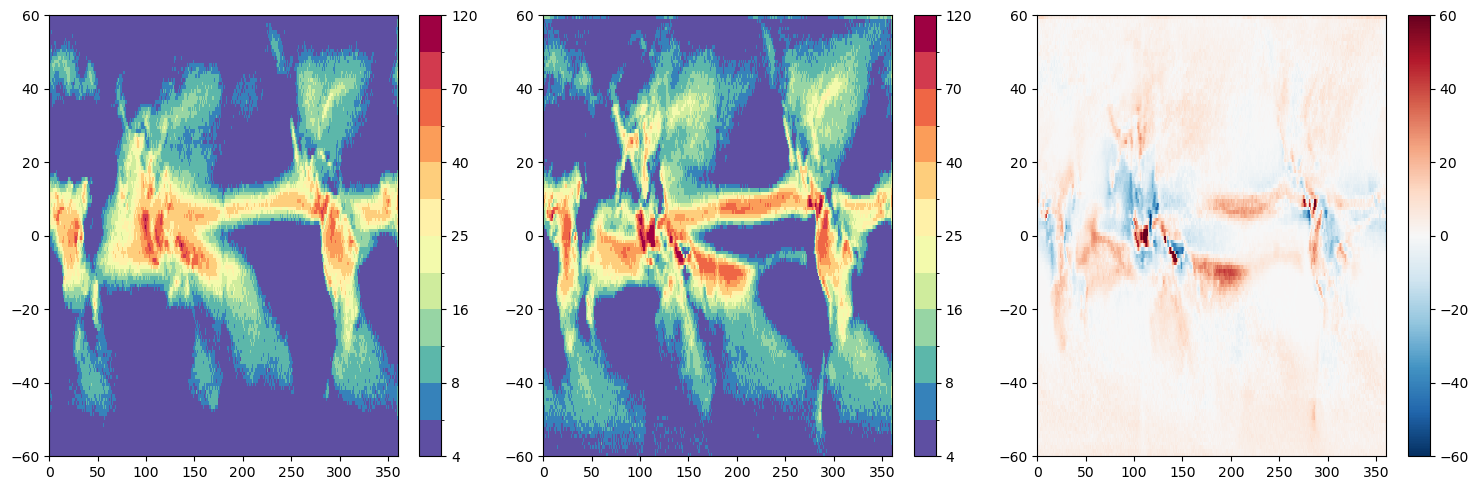

In [ ]:
fig, ax = plt.subplots(ncols=3, figsize=[15,5], dpi=100)
levels = [4,6,8,12,16,20,25,30,40,50,70,90,120]
cmap = copy.copy(mpl.colormaps.get_cmap("Spectral_r"))
norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=256)
mcs_irnumber_diff = mcs_irnumber_m1 - mcs_irnumber_obs
pm1 = ax[0].pcolormesh(xbins, ybins, mcs_irnumber_obs, shading='auto', norm=norm, cmap=cmap)
pm2 = ax[1].pcolormesh(xbins, ybins, mcs_irnumber_m1, shading='auto', norm=norm, cmap=cmap)
pm3 = ax[2].pcolormesh(xbins, ybins, mcs_irnumber_diff, shading='auto', vmin=-60, vmax=60, cmap='RdBu_r')
plt.colorbar(pm1, ax=ax[0])
plt.colorbar(pm2, ax=ax[1])
plt.colorbar(pm3, ax=ax[2])
fig.tight_layout()

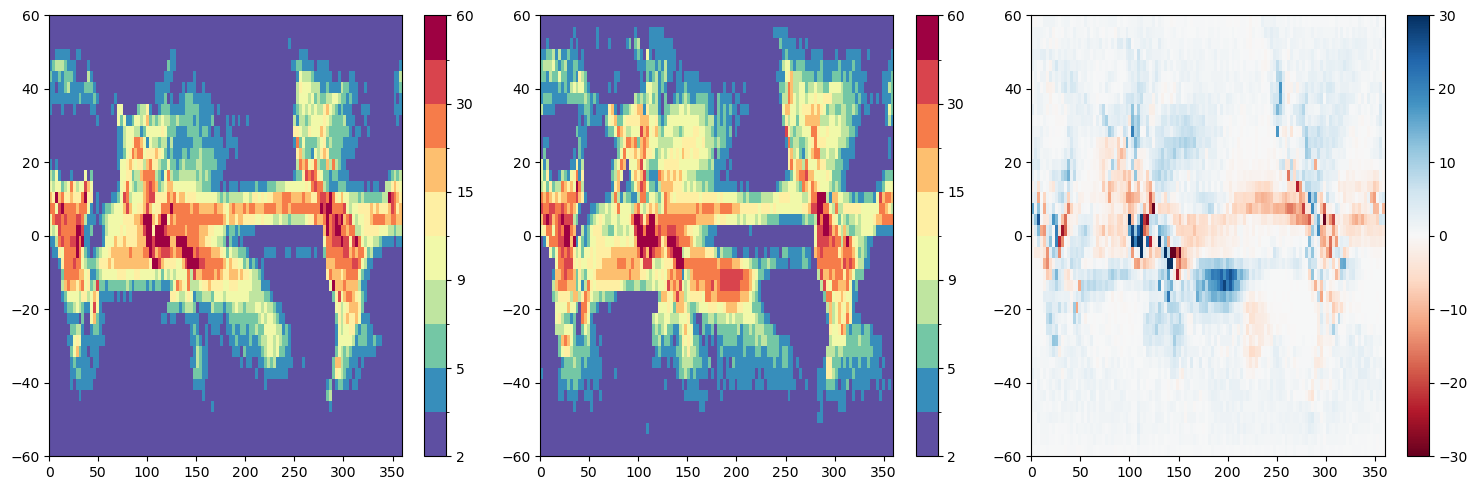

In [61]:
fig, ax = plt.subplots(ncols=3, figsize=[15,5], dpi=100)
levels = [2,3,5,7,9,12,15,20,30,40,60]
cmap = copy.copy(mpl.colormaps.get_cmap("Spectral_r"))
norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=256)
mcs_initcount_diff = mcs_initcount_m1 - mcs_initcount_obs
pm1 = ax[0].pcolormesh(xbins_c, ybins_c, mcs_initcount_obs, shading='auto', norm=norm, cmap=cmap)
pm2 = ax[1].pcolormesh(xbins_c, ybins_c, mcs_initcount_m1, shading='auto', norm=norm, cmap=cmap)
pm3 = ax[2].pcolormesh(xbins_c, ybins_c, mcs_initcount_diff, shading='auto', vmin=-30, vmax=30, cmap='RdBu')
plt.colorbar(pm1, ax=ax[0])
plt.colorbar(pm2, ax=ax[1])
plt.colorbar(pm3, ax=ax[2])
fig.tight_layout()

## Function to make N x M maps (with 1 colorbar for each panel)

In [64]:
def plot_map_panels(data_arrays, lonarray, latarray, levels, cmaps, titles, cblabels, cbticks,
                    figname, oob_colors=None,
                    projection=None, central_lon=225, lat_range=(-59.9, 59.9),
                    terrain_data=ter, terrain_levels=[1000, 10000],
                    mask=mask_miss, show_mask=False, lon_label=False, lat_label=False,
                    lon_ter=lon_ter, lat_ter=lat_ter, lon_mask=lon_mask, lat_mask=lat_mask,
                    figsize=None, fontsize=12, wspace=0.25, hspace=0.15, dpi=300):
    """
    Plot N x M global maps with Cartopy projection, ONE colorbar per panel.
    The grid shape (nrow x ncol) is determined by the shape of data_arrays, following
    the style of plot_nxm_maps_1colorbar (Robinson projection, GridSpec layout, terrain
    contours, missing-data mask), but keeps one colorbar per panel so e.g. a diverging
    difference panel can sit next to OBS/MODEL panels with independent color scales.

    Parameters:
    -----------
    data_arrays : list of lists
        2D list of 2D arrays [nrow][ncol], each on the (lonarray, latarray) grid
    lonarray, latarray : 1D arrays
        Bin edges used to build the data arrays (e.g., xbins/ybins or xbins_c/ybins_c)
    levels, cmaps, titles, cblabels, cbticks : list of lists, or a single value
        Per-panel contour levels / colormap / title / colorbar label / colorbar ticks.
        Pass a [nrow][ncol] nested list for per-panel control, or a single value to
        broadcast to every panel.
    oob_colors : dict, list of lists, or None
        {'over': color, 'under': color} per panel; pass None for a panel to disable
        (e.g. the difference panel). Pass a [nrow][ncol] nested list for per-panel
        control, or a single dict/None to broadcast to every panel.
    projection : cartopy projection
        Default: Robinson with central_lon
    lat_range : tuple
        (lat_min, lat_max) to clip the displayed map, e.g., (-59.9, 59.9)
    terrain_data, lon_ter, lat_ter : arrays
        Terrain elevation data and coordinates to overplot as contours
    terrain_levels : list
        Terrain contour levels to plot in gray
    mask, lon_mask, lat_mask : array / coords
        Missing-data mask (True = missing) and its coordinates
    show_mask : bool or list
        Whether to overlay the missing-data mask on each panel. Single bool, 1D list
        (per row or per column), or 2D list [nrow][ncol]
    lon_label, lat_label : bool or list
        Show longitude/latitude gridline labels. Single bool, 1D list (per row or per
        column), or 2D list [nrow][ncol]
    figsize : tuple or None
        Figure size (width, height). If None, computed from nrow/ncol
    wspace, hspace : float
        Spacing between panel columns/rows
    """
    nrow = len(data_arrays)
    ncol = len(data_arrays[0])

    # Broadcast a single value to a [nrow][ncol] nested list of per-panel parameters
    def ensure_panel_format(param, nrow, ncol):
        if (isinstance(param, list) and len(param) == nrow and
                all(isinstance(r, list) and len(r) == ncol for r in param)):
            return param
        return [[param for _ in range(ncol)] for _ in range(nrow)]

    # Convert a bool / 1D list / 2D list into a [nrow][ncol] nested bool list
    def ensure_grid_bool_format(param, nrow, ncol):
        if isinstance(param, bool):
            return [[param for _ in range(ncol)] for _ in range(nrow)]
        elif isinstance(param, list):
            if len(param) == 0:
                return [[False for _ in range(ncol)] for _ in range(nrow)]
            elif isinstance(param[0], list):
                # Already a 2D list
                return param
            elif isinstance(param[0], bool):
                if len(param) == nrow:
                    return [[param[r] for _ in range(ncol)] for r in range(nrow)]
                elif len(param) == ncol:
                    return [[param[c] for c in range(ncol)] for _ in range(nrow)]
                else:
                    return [[False for _ in range(ncol)] for _ in range(nrow)]
        return [[False for _ in range(ncol)] for _ in range(nrow)]

    levels = ensure_panel_format(levels, nrow, ncol)
    cmaps = ensure_panel_format(cmaps, nrow, ncol)
    titles = ensure_panel_format(titles, nrow, ncol)
    cblabels = ensure_panel_format(cblabels, nrow, ncol)
    cbticks = ensure_panel_format(cbticks, nrow, ncol)
    oob_colors = ensure_panel_format(oob_colors, nrow, ncol)
    show_mask = ensure_grid_bool_format(show_mask, nrow, ncol)
    lon_label = ensure_grid_bool_format(lon_label, nrow, ncol)
    lat_label = ensure_grid_bool_format(lat_label, nrow, ncol)

    if figsize is None:
        figwidth = 15
        figheight = nrow * (figwidth / ncol) * 0.4
        figsize = [figwidth, figheight]

    mpl.rcParams['font.size'] = fontsize
    mpl.rcParams['font.family'] = 'STIXGeneral'

    if projection is None:
        projection = ccrs.Robinson(central_longitude=central_lon)
    data_proj = ccrs.PlateCarree()
    resolution = '110m'
    land = cfeature.NaturalEarthFeature('physical', 'land', resolution)

    fig = plt.figure(figsize=figsize, dpi=100)

    # Main GridSpec: nrow x ncol, one slot per panel
    gs_main = gridspec.GridSpec(nrow, ncol, figure=fig, wspace=wspace, hspace=hspace)

    for row in range(nrow):
        for col in range(ncol):
            # Split this panel's slot into map + colorbar using GridSpecFromSubplotSpec
            gs_panel = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_main[row, col],
                                                          width_ratios=[1, 0.02], wspace=0.03)
            ax = plt.subplot(gs_panel[0], projection=projection)
            ax.set_global()
            ax.set_aspect('auto', adjustable=None)

            data = data_arrays[row][col]
            Zm = np.ma.masked_where(np.isnan(data), data)
            cmap = copy.copy(mpl.colormaps.get_cmap(cmaps[row][col]))
            norm = mpl.colors.BoundaryNorm(boundaries=levels[row][col], ncolors=cmap.N)
            cf1 = ax.pcolormesh(lonarray, latarray, Zm, shading='auto', norm=norm, cmap=cmap,
                                transform=data_proj, zorder=2)
            if oob_colors[row][col] is not None:
                cf1.cmap.set_over(oob_colors[row][col]['over'])
                cf1.cmap.set_under(oob_colors[row][col]['under'])
                cf1.set_clim(min(levels[row][col]), max(levels[row][col]))

            # Add land boundaries (no country borders)
            ax.add_feature(land, facecolor='none', edgecolor='k', linewidth=0.5, zorder=3)

            # Fill missing IR data region
            if (mask is not None) and show_mask[row][col]:
                cmap_zmask = mpl.colors.ListedColormap(['white', 'lightgray', 'lightgray'])
                norm_zmask = mpl.colors.BoundaryNorm(np.arange(0, 2.1, 1), cmap_zmask.N)
                Zmask = np.ma.masked_where(mask == False, mask)
                ax.pcolormesh(lon_mask, lat_mask, Zmask, cmap=cmap_zmask, norm=norm_zmask,
                             transform=data_proj, zorder=2)
                ax.text(-115, -54, 'Missing Data', color='k', ha='center', va='center',
                       transform=data_proj, zorder=3)

            # Terrain contours
            if terrain_data is not None and terrain_levels is not None:
                ax.contour(lon_ter, lat_ter, terrain_data, levels=terrain_levels,
                           colors='dimgray', linewidths=0.8, transform=data_proj, zorder=3)

            # Gridlines with optional per-panel lon/lat labels
            gl = ax.gridlines(draw_labels=lon_label[row][col] or lat_label[row][col],
                             linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
            if lon_label[row][col] or lat_label[row][col]:
                gl.top_labels = False
                gl.right_labels = False
                gl.bottom_labels = lon_label[row][col]
                gl.left_labels = lat_label[row][col]
                gl.xlabel_style = {'size': fontsize - 2}
                gl.ylabel_style = {'size': fontsize - 2}

            # Clip to lat_range
            if lat_range is not None:
                lat_min, lat_max = lat_range
                _, y_min = projection.transform_point(0, lat_min, data_proj)
                _, y_max = projection.transform_point(0, lat_max, data_proj)
                ax.set_ylim([y_min, y_max])

            if titles[row][col] is not None:
                ax.set_title(titles[row][col], loc='center', fontsize=fontsize, weight='bold')

            # ONE colorbar for this panel
            cax = plt.subplot(gs_panel[1])
            cb1 = plt.colorbar(cf1, cax=cax, label=cblabels[row][col], ticks=cbticks[row][col],
                              orientation='vertical', extend='both')

    # Work around to make tight_layout-like spacing work
    fig.canvas.draw()
    fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
    return fig

## MCS track density maps

In [ ]:
years = f'{int(syear_obs.min())}-{int(syear_obs.max())}'
years

/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/figures/IMERG_SCREAM_mcs_irnumber_map_annual.png


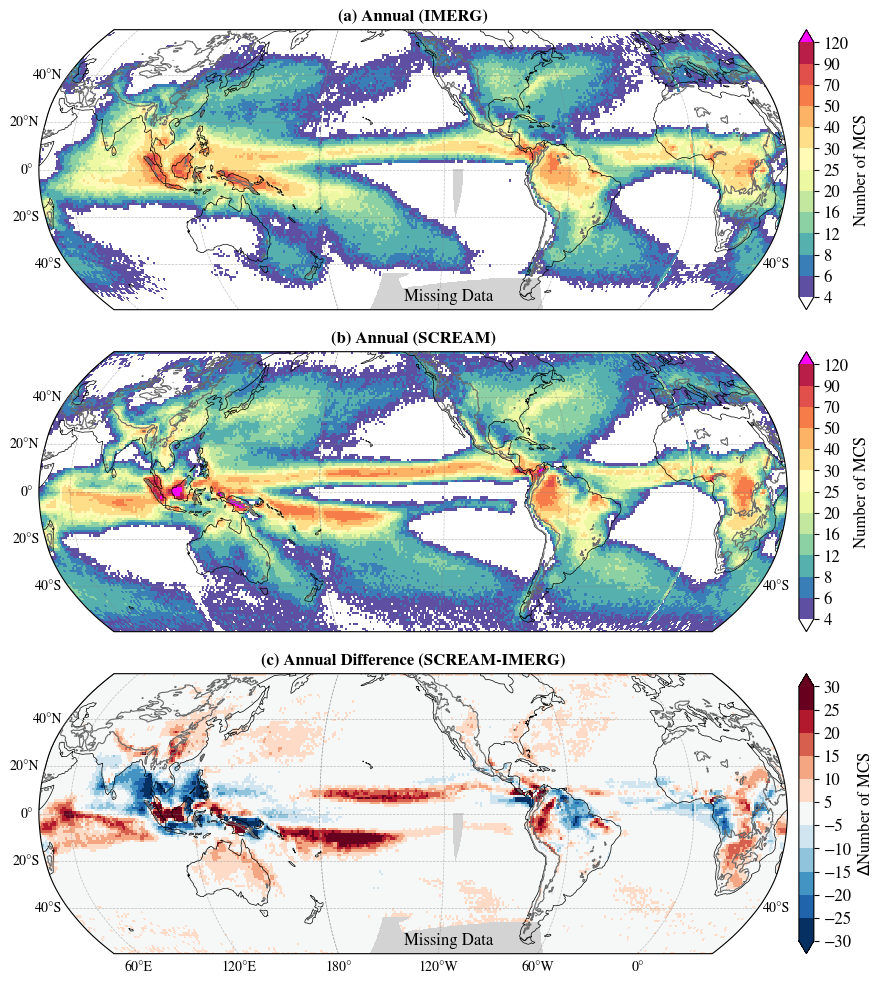

In [71]:
# Compute difference between model and observations
mcs_irnumber_diff = mcs_irnumber_m1 - mcs_irnumber_obs
# Prepare data array for plotting
dataarray = [[mcs_irnumber_obs], [mcs_irnumber_m1], [mcs_irnumber_diff]]
# Define levels
# levels = [2,3,5,7,9,12,15,20,30,40,50,60]
# levelsdiff = np.arange(-30,30.1,5)
levels = [4,6,8,12,16,20,25,30,40,50,70,90,120]
levelsdiff = np.arange(-30,30.1,5)
# Remove mid-point (0 value)
idx = int((len(levelsdiff)-1)/2)
levelsdiff = np.delete(levelsdiff, idx)
levels = [[levels], [levels], [levelsdiff]]
# Define colormaps
cmap = copy.copy(mpl.colormaps.get_cmap('Spectral_r'))
cmap = truncate_colormap(cmap, 0.0, 0.95)
cmapdiff = copy.copy(mpl.colormaps.get_cmap('RdBu_r'))
cmaps = [[cmap], [cmap], [cmapdiff]]
# Define titles, colorbar labels, and other plot settings
titles = [[f'(a) Annual ({SOURCES["obs"]["label"]})'], 
          [f'(b) Annual ({SOURCES["m1"]["label"]})'], 
          [f'(c) Annual Difference ({SOURCES["m1"]["label"]}-{SOURCES["obs"]["label"]})']]
cblabels = [['Number of MCS'], ['Number of MCS'], [r'$\Delta$'+'Number of MCS']]
cbticks = levels
# Out-of-bounds colors
oob_colors = [[{'under':'white', 'over':'magenta'}], [{'under':'white', 'over':'magenta'}], [None]]
# Latitude, longitude labels and mask settings
lat_label = [[True], [True], [True]]
lon_label = [[False], [False], [True]]
show_mask = [[True], [False], [True]]
fontsize = 12
figsize = (10, 12)
figname = f'{figdir}{SOURCES["obs"]["label"]}_{SOURCES["m1"]["label"]}_mcs_irnumber_map_annual.png'
fig = plot_map_panels(dataarray, xbins, ybins, levels, cmaps, titles, cblabels, cbticks, figname,
                      oob_colors=oob_colors, lat_label=lat_label, lon_label=lon_label, show_mask=show_mask,
                      figsize=figsize, fontsize=fontsize)
print(figname)

/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/figures/IMERG_SCREAM_mcs_irnumber_map_DJF.png


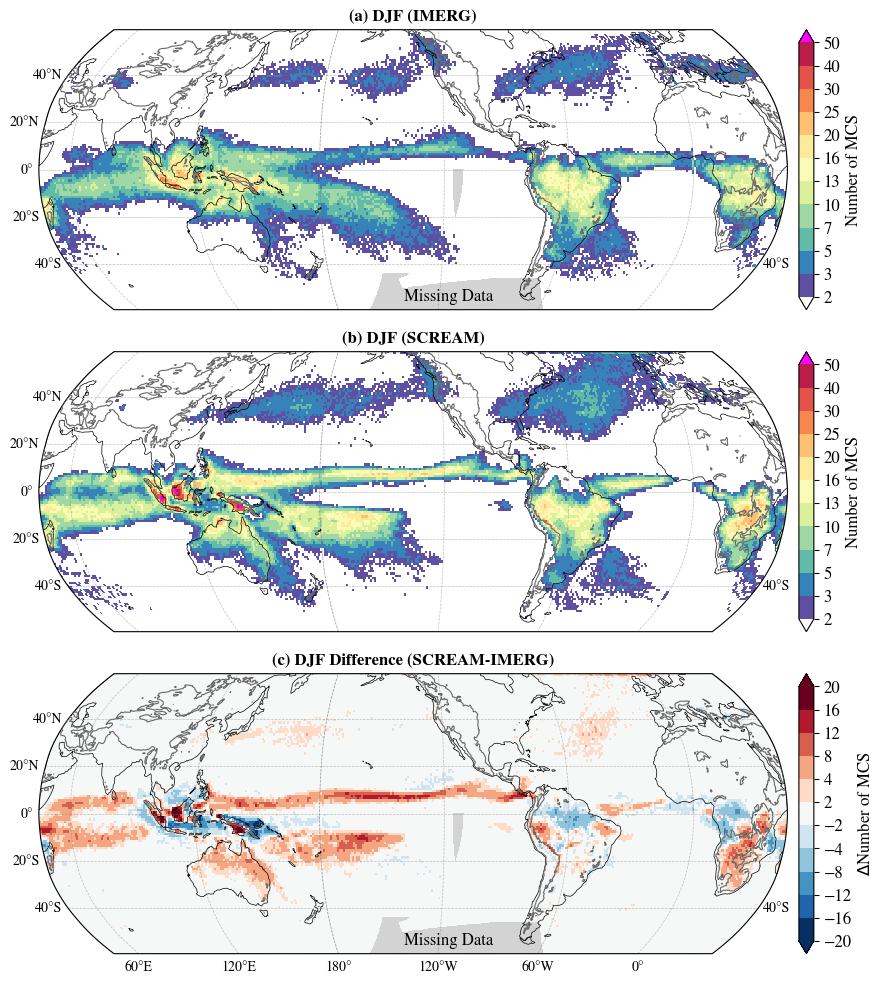

In [ ]:
season = 'DJF'
# Compute difference between model and observations
mcs_irnumber_diff_DJF = mcs_irnumber_m1_DJF - mcs_irnumber_obs_DJF
# Prepare data array for plotting
dataarray = [[mcs_irnumber_obs_DJF], [mcs_irnumber_m1_DJF], [mcs_irnumber_diff_DJF]]
# Define contour levels for plotting
# levels = [1,2,3,5,7,9,12,15,20,30]
# levelsdiff = np.arange(-15,15.1,3)
levels = [2,3,5,7,10,13,16,20,25,30,40,50]
levelsdiff = [-20,-16,-12,-8,-4,-2,2,4,8,12,16,20]
# levelsdiff = np.arange(-20,21,4)
# # Remove mid-point (0 value) from difference levels
# idx = int((len(levelsdiff)-1)/2)
# levelsdiff = np.delete(levelsdiff, idx)
levels = [[levels], [levels], [levelsdiff]]
# Define colormaps for plotting
cmap = copy.copy(mpl.colormaps.get_cmap('Spectral_r'))
cmap = truncate_colormap(cmap, 0.0, 0.95)
cmapdiff = copy.copy(mpl.colormaps.get_cmap('RdBu_r'))
cmaps = [[cmap], [cmap], [cmapdiff]]
# Define titles, colorbar labels, and other plot settings
titles = [[f'(a) {season} ({SOURCES["obs"]["label"]})'], 
          [f'(b) {season} ({SOURCES["m1"]["label"]})'], 
          [f'(c) {season} Difference ({SOURCES["m1"]["label"]}-{SOURCES["obs"]["label"]})']]
cblabels = [['Number of MCS'], ['Number of MCS'], [r'$\Delta$'+'Number of MCS']]
cbticks = levels
# Out-of-bounds colors
oob_colors = [[{'under':'white', 'over':'magenta'}], [{'under':'white', 'over':'magenta'}], [None]]
# Latitude and longitude labels, and mask settings
lat_label = [[True], [True], [True]]
lon_label = [[False], [False], [True]]
show_mask = [[True], [False], [True]]
figname = f'{figdir}{SOURCES["obs"]["label"]}_{SOURCES["m1"]["label"]}_mcs_irnumber_map_{season}.png'
figsize = (10, 12)
fontsize = 12
fig = plot_map_panels(dataarray, xbins, ybins, levels, cmaps, titles, cblabels, cbticks, figname,
                      oob_colors=oob_colors, lat_label=lat_label, lon_label=lon_label, show_mask=show_mask,
                      figsize=figsize, fontsize=fontsize)
print(figname)

/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/figures/IMERG_SCREAM_mcs_irnumber_map_MAM.png


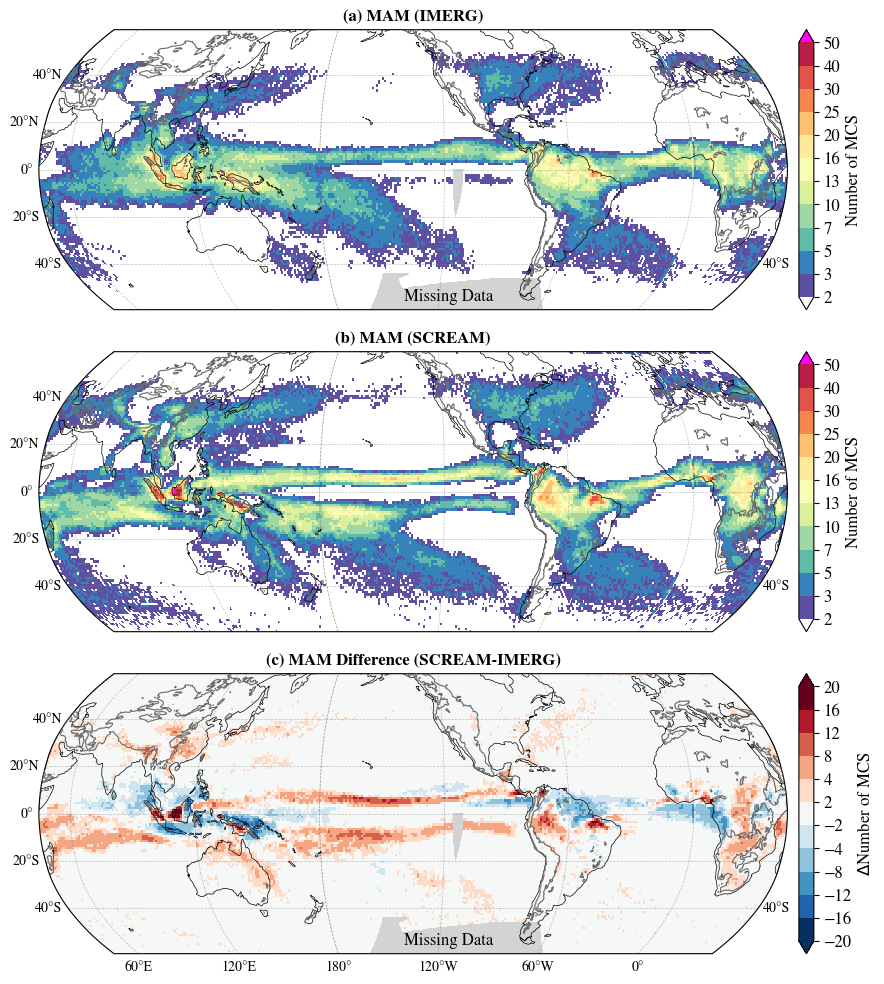

In [ ]:
season = 'MAM'
# Compute difference between model and observations
mcs_irnumber_diff_MAM = mcs_irnumber_m1_MAM - mcs_irnumber_obs_MAM
# Prepare data array for plotting
dataarray = [[mcs_irnumber_obs_MAM], [mcs_irnumber_m1_MAM], [mcs_irnumber_diff_MAM]]
# Define titles
titles = [[f'(a) {season} ({SOURCES["obs"]["label"]})'], 
          [f'(b) {season} ({SOURCES["m1"]["label"]})'], 
          [f'(c) {season} Difference ({SOURCES["m1"]["label"]}-{SOURCES["obs"]["label"]})']]
figname = f'{figdir}{SOURCES["obs"]["label"]}_{SOURCES["m1"]["label"]}_mcs_irnumber_map_{season}.png'
fig = plot_map_panels(dataarray, xbins, ybins, levels, cmaps, titles, cblabels, cbticks, figname,
                      oob_colors=oob_colors, lat_label=lat_label, lon_label=lon_label, show_mask=show_mask,
                      figsize=figsize, fontsize=fontsize)
print(figname)

/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/figures/IMERG_SCREAM_mcs_irnumber_map_JJA.png


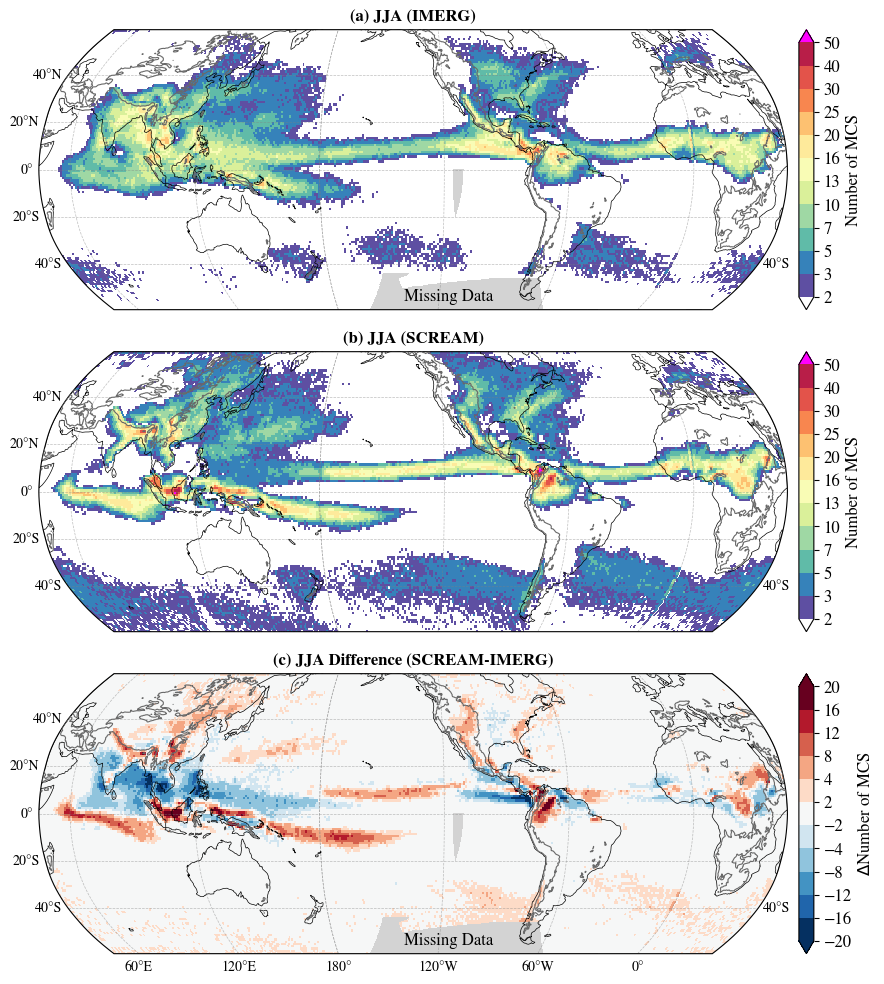

In [76]:
season = 'JJA'
# Compute difference between model and observations
mcs_irnumber_diff_JJA = mcs_irnumber_m1_JJA - mcs_irnumber_obs_JJA
# Prepare data array for plotting
dataarray = [[mcs_irnumber_obs_JJA], [mcs_irnumber_m1_JJA], [mcs_irnumber_diff_JJA]]
# Define titles
titles = [[f'(a) {season} ({SOURCES["obs"]["label"]})'], 
          [f'(b) {season} ({SOURCES["m1"]["label"]})'], 
          [f'(c) {season} Difference ({SOURCES["m1"]["label"]}-{SOURCES["obs"]["label"]})']]
figname = f'{figdir}{SOURCES["obs"]["label"]}_{SOURCES["m1"]["label"]}_mcs_irnumber_map_{season}.png'
fig = plot_map_panels(dataarray, xbins, ybins, levels, cmaps, titles, cblabels, cbticks, figname,
                      oob_colors=oob_colors, lat_label=lat_label, lon_label=lon_label, show_mask=show_mask,
                      figsize=figsize, fontsize=fontsize)
print(figname)

/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/figures/IMERG_SCREAM_mcs_irnumber_map_SON.png


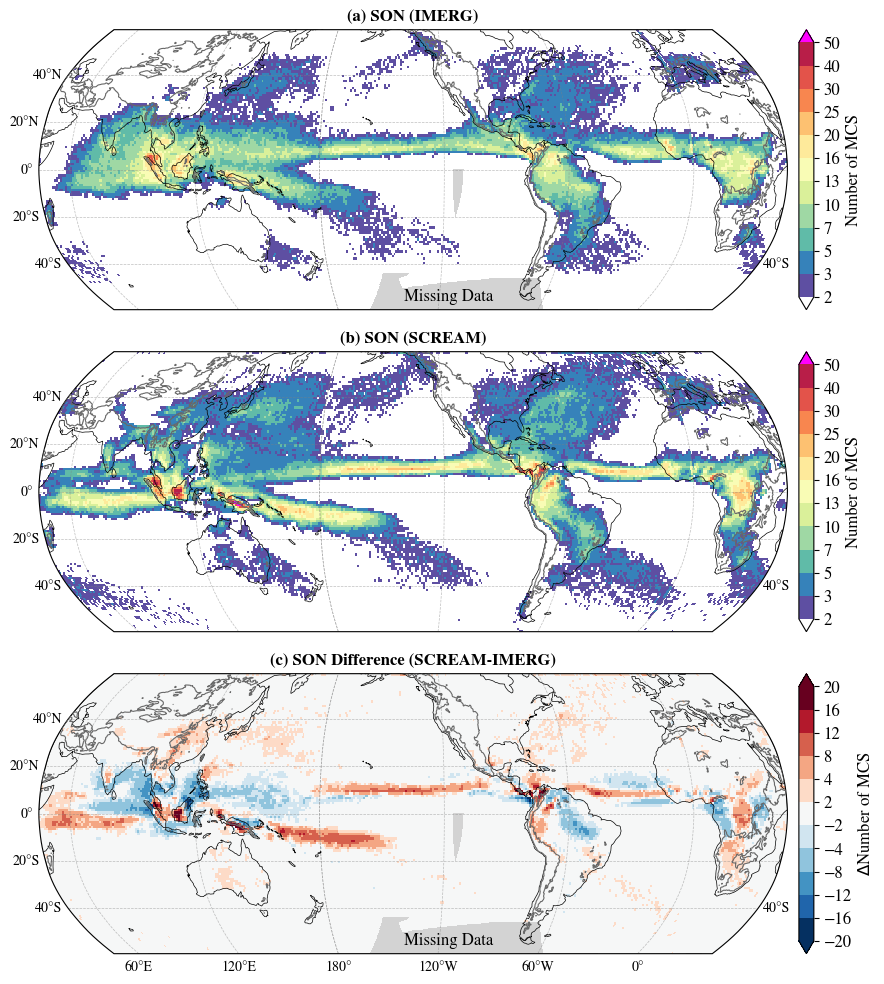

In [77]:
season = 'SON'
# Compute difference between model and observations
mcs_irnumber_diff_SON = mcs_irnumber_m1_SON - mcs_irnumber_obs_SON
# Prepare data array for plotting
dataarray = [[mcs_irnumber_obs_SON], [mcs_irnumber_m1_SON], [mcs_irnumber_diff_SON]]
# Define titles
titles = [[f'(a) {season} ({SOURCES["obs"]["label"]})'], 
          [f'(b) {season} ({SOURCES["m1"]["label"]})'], 
          [f'(c) {season} Difference ({SOURCES["m1"]["label"]}-{SOURCES["obs"]["label"]})']]
figname = f'{figdir}{SOURCES["obs"]["label"]}_{SOURCES["m1"]["label"]}_mcs_irnumber_map_{season}.png'
fig = plot_map_panels(dataarray, xbins, ybins, levels, cmaps, titles, cblabels, cbticks, figname,
                      oob_colors=oob_colors, lat_label=lat_label, lon_label=lon_label, show_mask=show_mask,
                      figsize=figsize, fontsize=fontsize)
print(figname)

## MCS initiation count maps

/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/figures/IMERG_SCREAM_mcs_irinitiation_map_annual.png


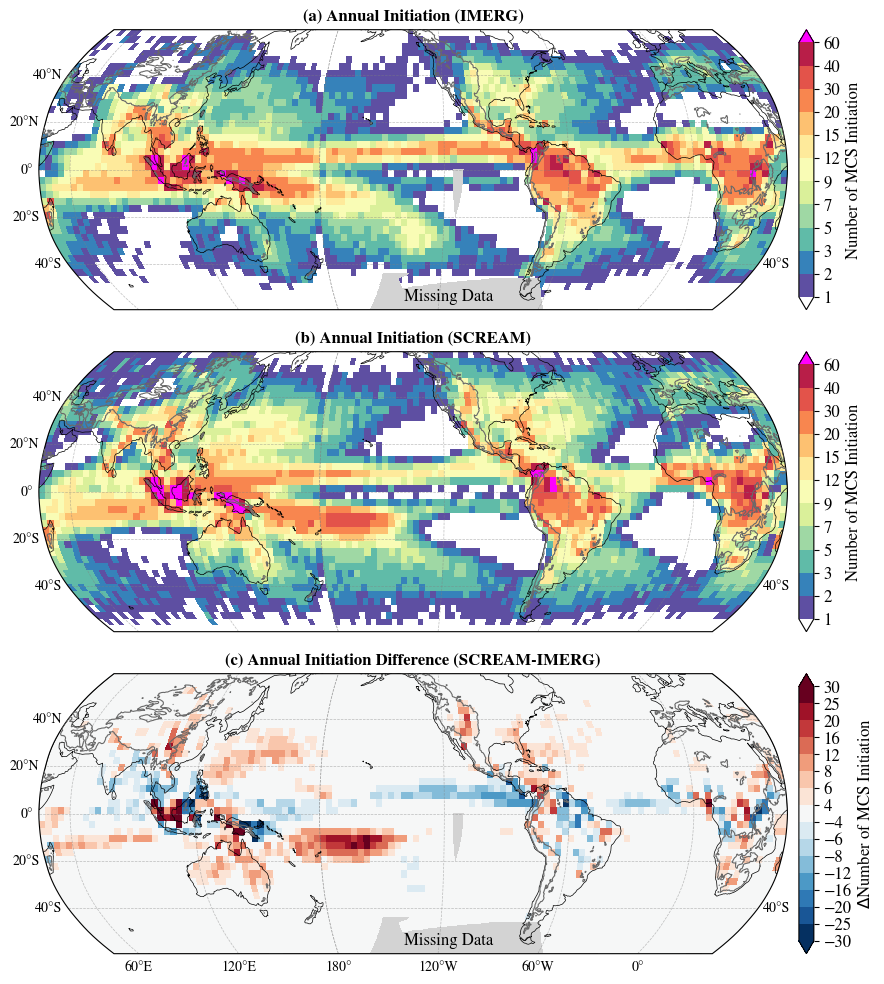

In [78]:
# Compute difference between model and observations for MCS initiation
mcs_initcount_diff = mcs_initcount_m1 - mcs_initcount_obs
# Prepare data array for plotting
dataarray = [[mcs_initcount_obs], [mcs_initcount_m1], [mcs_initcount_diff]]
# Define contour levels for plotting
levels = [1,2,3,5,7,9,12,15,20,30,40,60]
levelsdiff = [-30,-25,-20,-16,-12,-8,-6,-4,4,6,8,12,16,20,25,30]
levels = [[levels], [levels], [levelsdiff]]
# Define colormaps for plotting
cmap = copy.copy(mpl.colormaps.get_cmap('Spectral_r'))
cmap = truncate_colormap(cmap, 0.0, 0.95)
cmapdiff = copy.copy(mpl.colormaps.get_cmap('RdBu_r'))
cmaps = [[cmap], [cmap], [cmapdiff]]
# Define titles, colorbar labels, and other plot settings
titles = [[f'(a) Annual Initiation ({SOURCES["obs"]["label"]})'], 
          [f'(b) Annual Initiation ({SOURCES["m1"]["label"]})'], 
          [f'(c) Annual Initiation Difference ({SOURCES["m1"]["label"]}-{SOURCES["obs"]["label"]})']]
cblabels = [['Number of MCS Initiation'], ['Number of MCS Initiation'], [r'$\Delta$'+'Number of MCS Initiation']]
cbticks = levels
# Out-of-bounds colors
oob_colors = [[{'under':'white', 'over':'magenta'}], [{'under':'white', 'over':'magenta'}], [None]]
# Latitude and longitude labels, and mask settings
lat_label = [[True], [True], [True]]
lon_label = [[False], [False], [True]]
show_mask = [[True], [False], [True]]
figname = f'{figdir}{SOURCES["obs"]["label"]}_{SOURCES["m1"]["label"]}_mcs_irinitiation_map_annual.png'
fig = plot_map_panels(dataarray, xbins_c, ybins_c, levels, cmaps, titles, cblabels, cbticks, figname,
                      oob_colors=oob_colors, lat_label=lat_label, lon_label=lon_label, show_mask=show_mask,
                      figsize=figsize, fontsize=fontsize)
print(figname)

/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/figures/IMERG_SCREAM_mcs_irinitiation_map_DJF.png


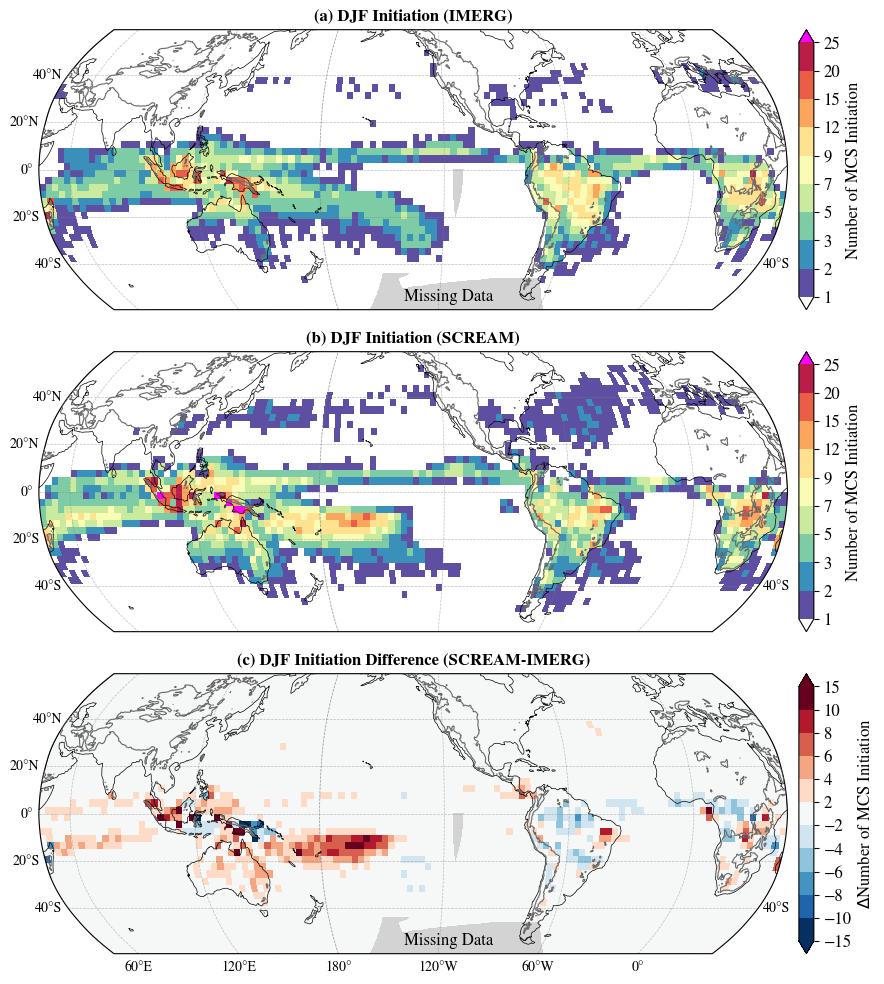

In [79]:
season = 'DJF'
# Compute difference between model and observations for DJF
mcs_initcount_diff_DJF = mcs_initcount_m1_DJF - mcs_initcount_obs_DJF
# Prepare data array for plotting
dataarray = [[mcs_initcount_obs_DJF], [mcs_initcount_m1_DJF], [mcs_initcount_diff_DJF]]
# Define contour levels for plotting
levels = [1,2,3,5,7,9,12,15,20,25]
levelsdiff = [-15,-10,-8,-6,-4,-2,2,4,6,8,10,15]
levels = [[levels], [levels], [levelsdiff]]
# Define colormaps for plotting
cmap = copy.copy(mpl.colormaps.get_cmap('Spectral_r'))
cmap = truncate_colormap(cmap, 0.0, 0.95)
cmapdiff = copy.copy(mpl.colormaps.get_cmap('RdBu_r'))
cmaps = [[cmap], [cmap], [cmapdiff]]
# Define titles, colorbar labels, and other plot settings
titles = [[f'(a) {season} Initiation ({SOURCES["obs"]["label"]})'], 
          [f'(b) {season} Initiation ({SOURCES["m1"]["label"]})'], 
          [f'(c) {season} Initiation Difference ({SOURCES["m1"]["label"]}-{SOURCES["obs"]["label"]})']]
cblabels = [['Number of MCS Initiation'], ['Number of MCS Initiation'], [r'$\Delta$'+'Number of MCS Initiation']]
cbticks = levels
# Out-of-bounds colors
oob_colors = [[{'under':'white', 'over':'magenta'}], [{'under':'white', 'over':'magenta'}], [None]]
# Latitude and longitude labels, and mask settings
lat_label = [[True], [True], [True]]
lon_label = [[False], [False], [True]]
show_mask = [[True], [False], [True]]
figname = f'{figdir}{SOURCES["obs"]["label"]}_{SOURCES["m1"]["label"]}_mcs_irinitiation_map_{season}.png'
fig = plot_map_panels(dataarray, xbins_c, ybins_c, levels, cmaps, titles, cblabels, cbticks, figname,
                      oob_colors=oob_colors, lat_label=lat_label, lon_label=lon_label, show_mask=show_mask,
                      figsize=figsize, fontsize=fontsize)
print(figname)

/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/figures/IMERG_SCREAM_mcs_irinitiation_map_MAM.png


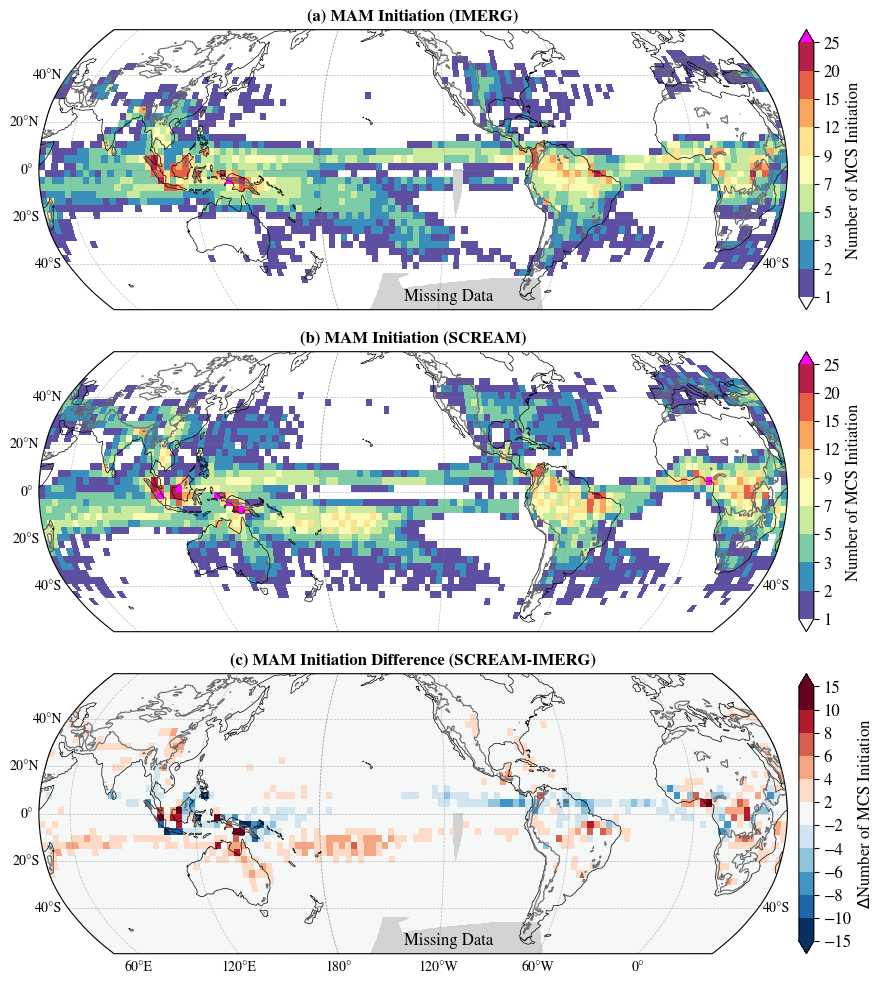

In [ ]:
season = 'MAM'
# Compute difference between model and observations for MAM
mcs_initcount_diff_MAM = mcs_initcount_m1_MAM - mcs_initcount_obs_MAM
# Prepare data array for plotting
dataarray = [[mcs_initcount_obs_MAM], [mcs_initcount_m1_MAM], [mcs_initcount_diff_MAM]]
# Define titles
titles = [[f'(a) {season} Initiation ({SOURCES["obs"]["label"]})'], 
          [f'(b) {season} Initiation ({SOURCES["m1"]["label"]})'], 
          [f'(c) {season} Initiation Difference ({SOURCES["m1"]["label"]}-{SOURCES["obs"]["label"]})']]

figname = f'{figdir}{SOURCES["obs"]["label"]}_{SOURCES["m1"]["label"]}_mcs_irinitiation_map_{season}.png'
fig = plot_map_panels(dataarray, xbins_c, ybins_c, levels, cmaps, titles, cblabels, cbticks, figname,
                      oob_colors=oob_colors, lat_label=lat_label, lon_label=lon_label, show_mask=show_mask,
                      figsize=figsize, fontsize=fontsize)
print(figname)

/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/figures/IMERG_SCREAM_mcs_irinitiation_map_JJA.png


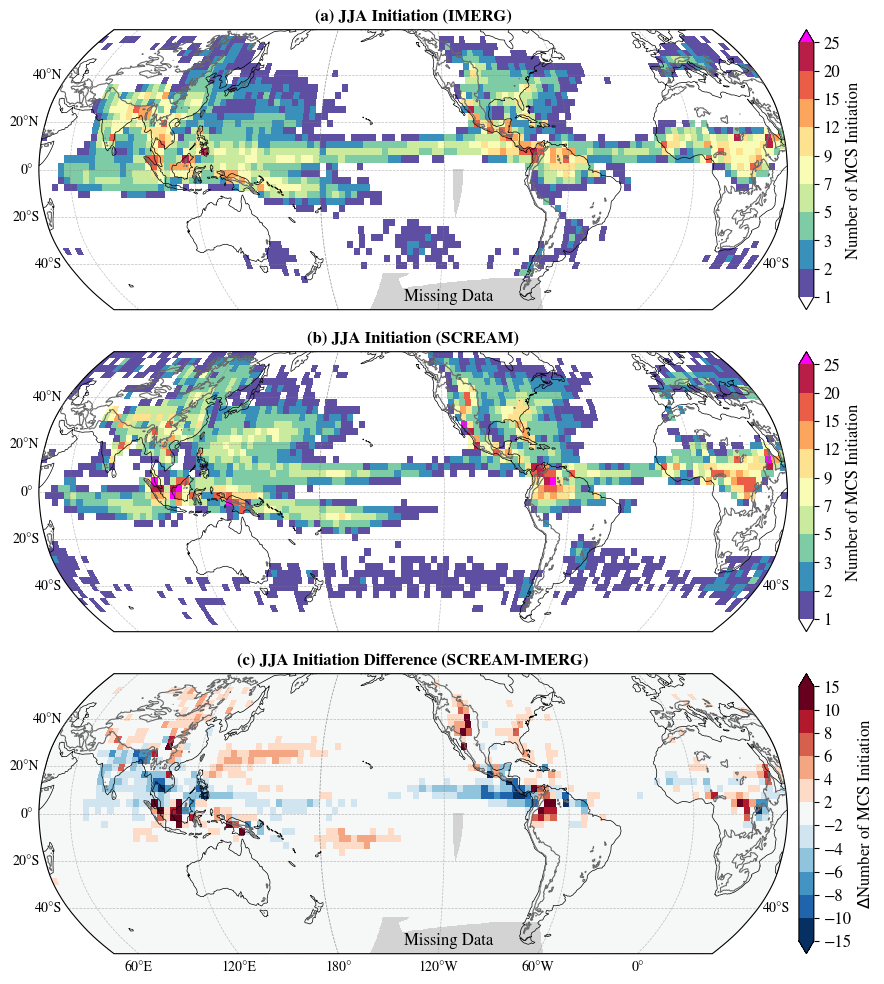

In [81]:
season = 'JJA'
# Compute difference between model and observations for JJA
mcs_initcount_diff_JJA = mcs_initcount_m1_JJA - mcs_initcount_obs_JJA
# Prepare data array for plotting
dataarray = [[mcs_initcount_obs_JJA], [mcs_initcount_m1_JJA], [mcs_initcount_diff_JJA]]
# Define titles
titles = [[f'(a) {season} Initiation ({SOURCES["obs"]["label"]})'], 
          [f'(b) {season} Initiation ({SOURCES["m1"]["label"]})'], 
          [f'(c) {season} Initiation Difference ({SOURCES["m1"]["label"]}-{SOURCES["obs"]["label"]})']]

figname = f'{figdir}{SOURCES["obs"]["label"]}_{SOURCES["m1"]["label"]}_mcs_irinitiation_map_{season}.png'
fig = plot_map_panels(dataarray, xbins_c, ybins_c, levels, cmaps, titles, cblabels, cbticks, figname,
                      oob_colors=oob_colors, lat_label=lat_label, lon_label=lon_label, show_mask=show_mask,
                      figsize=figsize, fontsize=fontsize)
print(figname)

/global/cfs/cdirs/m1867/zfeng/SCREAM-decadal/figures/IMERG_SCREAM_mcs_irinitiation_map_SON.png


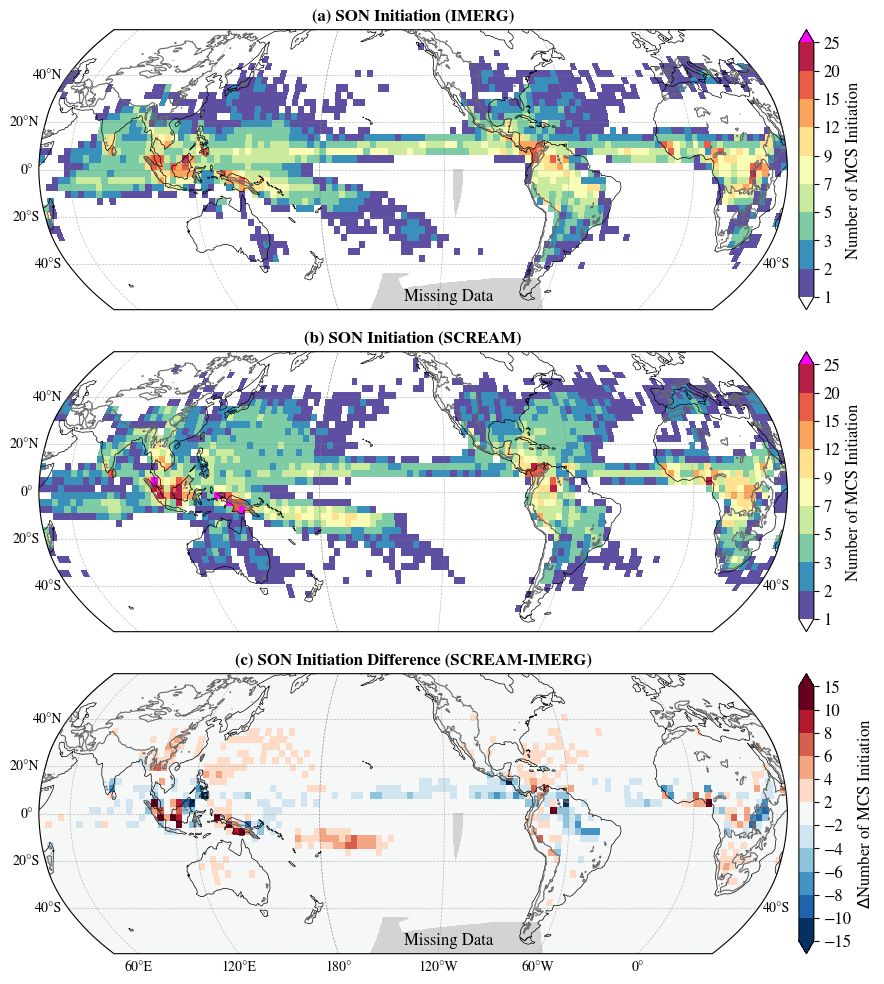

In [82]:
season = 'SON'
# Compute difference between model and observations for SON
mcs_initcount_diff_SON = mcs_initcount_m1_SON - mcs_initcount_obs_SON
# Prepare data array for plotting
dataarray = [[mcs_initcount_obs_SON], [mcs_initcount_m1_SON], [mcs_initcount_diff_SON]]
# Define titles
titles = [[f'(a) {season} Initiation ({SOURCES["obs"]["label"]})'], 
          [f'(b) {season} Initiation ({SOURCES["m1"]["label"]})'], 
          [f'(c) {season} Initiation Difference ({SOURCES["m1"]["label"]}-{SOURCES["obs"]["label"]})']]

figname = f'{figdir}{SOURCES["obs"]["label"]}_{SOURCES["m1"]["label"]}_mcs_irinitiation_map_{season}.png'
fig = plot_map_panels(dataarray, xbins_c, ybins_c, levels, cmaps, titles, cblabels, cbticks, figname,
                      oob_colors=oob_colors, lat_label=lat_label, lon_label=lon_label, show_mask=show_mask,
                      figsize=figsize, fontsize=fontsize)
print(figname)